In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import sys

if "../" not in sys.path:
    sys.path.append("../")

In [25]:
import os
import time
import tqdm

import src.helpers as helpers
import src.environments.cristal as cristal

import src.controllers.dqn as dqn
import src.controllers.ppo as ppo
import src.controllers.clothoids as clothoids
import src.controllers.purepursuit as purepursuit

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [26]:
environment = cristal.make_environment(
    discrete=False,
    random_obstacles=False,
    render_mode="rgb_array"
)

In [27]:
controller = clothoids.ClothoidTentaclesController(
    environment=environment,
    num_tentacles=41,
    t0=10.0,
    l0=10.0,
    min_tentacle_length=10.0,  # Ensure reasonable tentacle length at low speeds
    num_points_per_tentacle=64,

    # clearance, curvature, trajectory
    weights=(0.1, 0.2, 0.5),

    target_velocity=3.5,
)

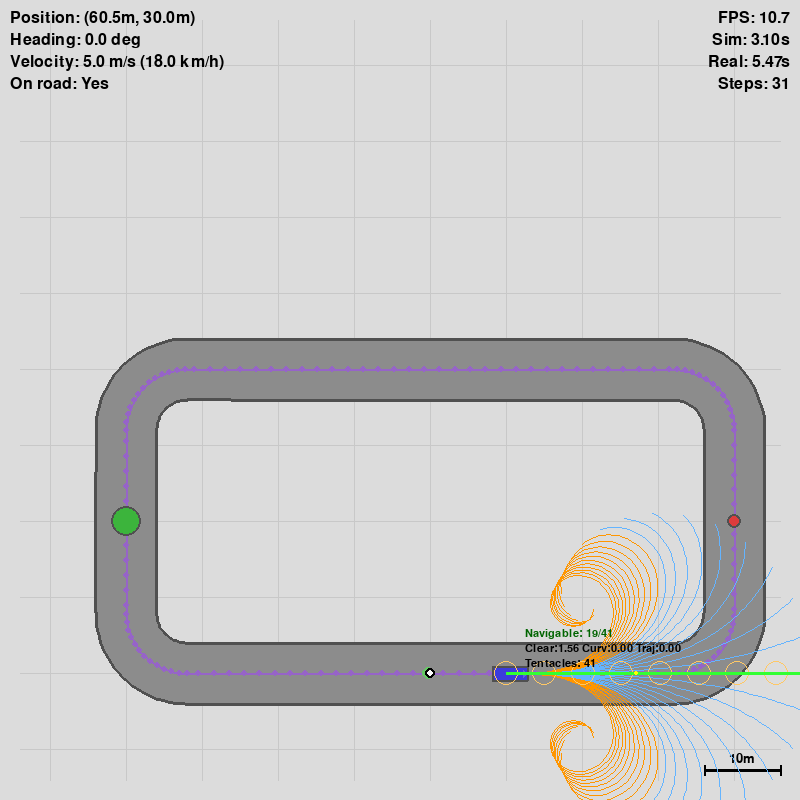

KeyboardInterrupt: 

In [28]:
# controller = purepursuit.PurePursuitController()

observation, info = environment.reset()

for i in range(500):
    # TODO: what are the _states ?
    action, _states = controller.get_action(observation=observation)
    
    print(action)
    
    observation, reward, terminated, truncated, info = environment.step(action)
    
    environment.unwrapped.overlay_manager.clear()
    controller.draw_debug(observation=observation, path=environment.unwrapped.path)
    
    helpers.preview(environment)

    if terminated or truncated:
        break

environment.close()